#Phase 5 Risk Adjusted Performance

##1 Imports 

In [1]:
import sys
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

project_root = Path.cwd().parent
sys.path.append(str(project_root))

##2 Load Daily Returns 

In [4]:
data_path = project_root / "data" / "processed" / "daily_returns.csv"

daily_returns = pd.read_csv(
    data_path, 
    index_col = 0,
    parse_dates= True
)
daily_returns.head()

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
Date,,,,,,,,
2016-01-05,0.002819,-0.004034,0.001691,0.001729,0.008521,-0.025059,0.004180,0.003538
2016-01-06,0.014441,0.013475,-0.012614,-0.014436,-0.008321,-0.019570,-0.005055,-0.005405
2016-01-07,0.014140,0.001795,-0.023992,-0.040440,-0.016006,-0.042204,-0.011654,-0.016541
2016-01-08,-0.004428,0.004479,-0.010977,-0.022399,-0.020202,0.005288,-0.010683,-0.002643
2016-01-11,-0.008895,-0.010944,0.000990,-0.001528,-0.013388,0.016192,-0.006010,0.001687


##3 Annual Returns 

In [5]:
annual_returns = (1 + daily_returns).prod()**(252/len(daily_returns)) - 1
annual_returns

GLD     0.131987
TLT    -0.007847
SPY     0.151494
JPM     0.206839
XOM     0.114620
AAPL    0.282896
JNJ     0.123151
KO      0.098636
dtype: float64

##4 Annual Volatility

In [8]:
annual_volatility = daily_returns.std()*np.sqrt(252)
annual_volatility

GLD     0.162449
TLT     0.147469
SPY     0.178086
JPM     0.274041
XOM     0.279524
AAPL    0.289163
JNJ     0.184832
KO      0.181695
dtype: float64

##5 Sharpe Ratio

In [9]:
sharpe_ratio = annual_returns/annual_volatility
sharpe_ratio

GLD     0.812481
TLT    -0.053212
SPY     0.850677
JPM     0.754775
XOM     0.410056
AAPL    0.978327
JNJ     0.666286
KO      0.542866
dtype: float64

##6 Ranking Assets

In [10]:
sharpe_ratio.sort_values(ascending=False)

AAPL    0.978327
SPY     0.850677
GLD     0.812481
JPM     0.754775
JNJ     0.666286
KO      0.542866
XOM     0.410056
TLT    -0.053212
dtype: float64

##7 Summary

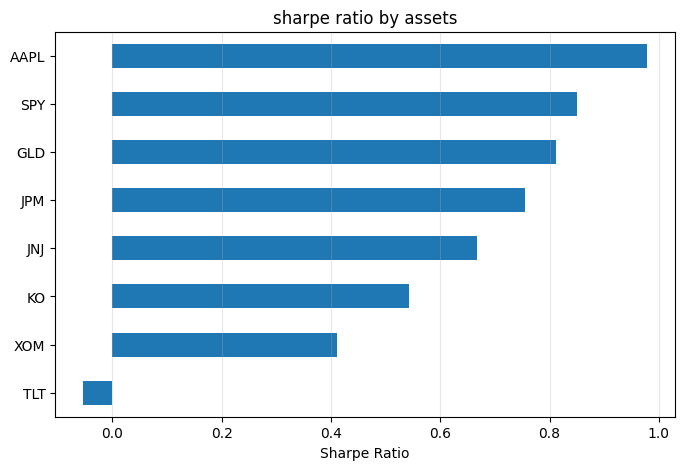

In [12]:
sharpe_ratio.sort_values().plot(
    kind = "barh", 
    figsize = (8,5),
    title = "sharpe ratio by assets"
)
plt.xlabel("Sharpe Ratio")
plt.grid(axis= "x", alpha = 0.3)
plt.show()

In [13]:
weights = np.array([1/8]*8)
portfolio_returns = daily_returns.dot(weights)


In [14]:
portfolio_annual_returns = (1 + portfolio_returns).prod()**(252/len(portfolio_returns)) -1 
print(f"portfolio annual return:{portfolio_annual_returns:.2%}")


portfolio annual return:15.34%


In [15]:
portfolio_annual_volatility = portfolio_returns.std()*np.sqrt(252)
print(f"portfolio annual volatility:{portfolio_annual_volatility:.2%}")

portfolio annual volatility:12.58%


In [16]:
portfolio_sharpe = portfolio_annual_returns/portfolio_annual_volatility
print(f"portfolio sharpe:{portfolio_sharpe:.2%}")

portfolio sharpe:121.91%


In [17]:
comparison = sharpe_ratio.copy()
comparison["Portfolio"] = portfolio_sharpe
comparison.sort_values(ascending = False)


Portfolio    1.219116
AAPL         0.978327
SPY          0.850677
GLD          0.812481
JPM          0.754775
JNJ          0.666286
KO           0.542866
XOM          0.410056
TLT         -0.053212
dtype: float64